# 00 Quickstart
## Цель ноутбука
Это обзорный ноутбук: здесь показан полный мини-проход по проекту - от настройки параметров до чтения результатов.

## Что мы делаем
- задаем параметры эксперимента;
- собираем notebook-конфиг;
- смотрим на один пример сигнального pipeline;
- запускаем небольшой эксперимент;
- читаем таблицу, графики и краткий автоматический вывод.

## Что получим в конце
- директорию `outputs/runs/<run_name>/` с артефактами запуска;
- таблицу результатов и графики;
- короткий вывод о качестве и времени декодирования.

## Как этот ноутбук связан с остальными
- `00` - быстрый обзор всего пайплайна;
- `01` - только baseline-алгоритмы;
- `02` и `03` - обучение neural-моделей;
- `04` - основной итоговый ноутбук сравнения;
- `05` - проверка воспроизводимости на сохраненных сигналах.

## Какие параметры можно менять
Ниже можно менять `K`, `num_blocks`, `snr_db_list`, `seed`, `decoders`, `epochs`, `learning_rate`, `hidden_dim`, `reuse_saved_signals`, `training_enabled`, `run_name`.
Подробная расшифровка каждого параметра дана ниже в отдельном разделе.

### Примеры режимов запуска
- **Smoke-run**: `K=32`, `num_blocks=4`, `snr_db_list=[0]` - самый быстрый тест, чтобы убедиться, что пайплайн работает.
- **Demo-run**: `K=64`, `num_blocks=20`, `snr_db_list=[0, 2]` - компактный демонстрационный сценарий.
- **Более содержательный запуск**: `K=256`, `num_blocks>=100`, `snr_db_list=[0, 1, 2, 3, 4]` - вариант для более гладких кривых и более устойчивых оценок.

In [1]:
# [1/8] Импорты и поиск корня проекта
from pathlib import Path
import sys
import yaml
import pandas as pd
from IPython.display import display, Image

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    while cur != cur.parent:
        if (cur / 'pyproject.toml').exists():
            return cur
        cur = cur.parent
    raise RuntimeError('Repo root not found')

ROOT = find_repo_root(Path.cwd())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

print('[1/8] Импорты загружены')
print('ROOT =', ROOT)


[1/8] Импорты загружены
ROOT = /tmp/dpcheck/dp-codex-create-repository-for-neural-viterbi-and-bcjr-j6ug56


# Настройка параметров эксперимента


In [2]:
# [2/8] Параметры эксперимента (редактируются в этой ячейке)
PARAMS = {
    'run_name': 'notebook_demo_run',
    'K': 64,
    'num_blocks': 12,
    'snr_db_list': [0, 2],
    'seed': 123,
    'decoders': ['viterbi', 'bcjr', 'neural_viterbi', 'neural_bcjr'],
    'epochs': 1,
    'learning_rate': 1e-3,
    'hidden_dim': 16,
    'reuse_saved_signals': False,
    'training_enabled': True,
}
print('[2/8] Параметры заданы')
display(pd.Series(PARAMS))


[2/8] Параметры заданы


run_name                                          notebook_demo_run
K                                                                64
num_blocks                                                       12
snr_db_list                                                  [0, 2]
seed                                                            123
decoders               [viterbi, bcjr, neural_viterbi, neural_bcjr]
epochs                                                            1
learning_rate                                                 0.001
hidden_dim                                                       16
reuse_saved_signals                                           False
training_enabled                                               True
dtype: object

### Расшифровка параметров эксперимента
- `K` - длина информационного блока. Чем больше `K`, тем содержательнее эксперимент, но тем дольше кодирование, декодирование и обучение.
- `num_blocks` - число блоков на каждую точку SNR. Чем больше блоков, тем надежнее оценки BER и FER.
- `snr_db_list` - список значений SNR в дБ. Несколько значений дают кривые качества, а не одну точку.
- `seed` - фиксирует генерацию случайных данных и шума для воспроизводимости.
- `decoders` - список декодеров, которые будут запущены и сравнены.
- `epochs` - число эпох обучения neural-калибраторов.
- `learning_rate` - шаг оптимизации при обучении.
- `hidden_dim` - размер скрытого слоя в neural-моделях.
- `reuse_saved_signals` - если `True`, повторно используется уже сохраненный `signals.npz`.
- `training_enabled` - включает или отключает обучение neural-моделей внутри `run_experiment`.
- `run_name` - имя директории, в которую будут сохранены все результаты запуска.

In [3]:
# [3/8] Загружаем YAML, меняем параметры и сохраняем notebook-конфиг
from comm_ai.utils.io import load_yaml

cfg = load_yaml(ROOT / 'src/comm_ai/config/experiments/awgn_small.yaml')
cfg['experiment']['run_name'] = PARAMS['run_name']
cfg['experiment']['K'] = PARAMS['K']
cfg['experiment']['num_blocks'] = PARAMS['num_blocks']
cfg['experiment']['snr_db_list'] = PARAMS['snr_db_list']
cfg['experiment']['seed'] = PARAMS['seed']
cfg['experiment']['decoders'] = PARAMS['decoders']
cfg['experiment']['reuse_saved_signals'] = PARAMS['reuse_saved_signals']

# Все результаты ноутбуков сохраняем в корневую папку проекта, а не рядом с ноутбуком
cfg['paths']['outputs_root'] = str(ROOT / 'outputs' / 'runs')

cfg['training']['enabled'] = PARAMS['training_enabled']
cfg['training']['epochs'] = PARAMS['epochs']
cfg['training']['learning_rate'] = PARAMS['learning_rate']
cfg['training']['hidden_dim'] = PARAMS['hidden_dim']

nb_cfg_path = ROOT / 'outputs/runs' / f"{PARAMS['run_name']}_notebook_config.yaml"
nb_cfg_path.parent.mkdir(parents=True, exist_ok=True)
nb_cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False), encoding='utf-8')
print('[3/8] Конфиг сохранён в', nb_cfg_path)


[3/8] Конфиг сохранён в /tmp/dpcheck/dp-codex-create-repository-for-neural-viterbi-and-bcjr-j6ug56/outputs/runs/notebook_demo_run_notebook_config.yaml


### Промежуточный вывод
На этом шаге сформирован отдельный YAML-конфиг для ноутбука. Его можно использовать повторно: запускать через CLI, менять вручную или сохранять как основу для новых экспериментов.

In [4]:
# [4/8] Пример сигнального pipeline: u -> c -> x -> noise -> y -> llr
from comm_ai.datasets.signals_dataset import SignalsDataset

ds_preview = SignalsDataset.generate(cfg)
print('[4/8] Сформирован пример одного набора сигналов для иллюстрации pipeline')
print('u[:16]     =', ds_preview.u[0][:16])
print('c[:16]     =', ds_preview.c[0][:16])
print('x[:16]     =', ds_preview.x[0][:16])
print('noise[:16] =', ds_preview.noise[0][:16])
print('y[:16]     =', ds_preview.y[0][:16])
print('llr[:16]   =', ds_preview.llr[0][:16])
print('Комментарий: чем меньше SNR, тем сильнее шум и сложнее декодирование.')


[4/8] Сформирован пример одного набора сигналов для иллюстрации pipeline
u[:16]     = [0 1 1 0 1 0 0 0 0 0 0 1 0 1 0 0]
c[:16]     = [0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 0]
x[:16]     = [ 1.  1. -1. -1. -1.  1.  1. -1.  1.  1.  1. -1.  1. -1. -1.  1.]
noise[:16] = [ 1.22622929 -2.17204389 -0.37014735  0.16438007  0.85988118  1.76166124
  0.99332378 -0.29152143  0.72812756 -1.26160032  1.42993853 -0.15647532
 -0.67375915 -0.6390601  -0.06136133 -0.39278492]
y[:16]     = [ 2.22622929 -1.17204389 -1.37014735 -0.83561993 -0.14011882  2.76166124
  1.99332378 -1.29152143  1.72812756 -0.26160032  2.42993853 -1.15647532
  0.32624085 -1.6390601  -1.06136133  0.60721508]
llr[:16]   = [ 4.45245859 -2.34408777 -2.74029469 -1.67123986 -0.28023763  5.52332247
  3.98664755 -2.58304285  3.45625512 -0.52320063  4.85987705 -2.31295065
  0.6524817  -3.2781202  -2.12272266  1.21443015]
Комментарий: чем меньше SNR, тем сильнее шум и сложнее декодирование.


### Промежуточный вывод
Ниже показан один конкретный пример прохождения данных через весь pipeline: от исходных битов до зашумленного сигнала и LLR. Это помогает увидеть, какие именно массивы затем поступают на вход декодерам.

In [5]:
# [5/8] Запуск эксперимента
from comm_ai.experiments.run_experiment import run
out_dir = run(str(nb_cfg_path))
print('[5/8] Эксперимент завершён, артефакты в', out_dir)


train_neural_viterbi:   0%|          | 0/1 [00:00<?, ?it/s]

train_neural_viterbi: 100%|██████████| 1/1 [00:00<00:00,  3.27it/s]

train_neural_viterbi: 100%|██████████| 1/1 [00:00<00:00,  3.23it/s]

train_neural_bcjr:   0%|          | 0/1 [00:00<?, ?it/s]

train_neural_bcjr: 100%|██████████| 1/1 [00:00<00:00,  4.98it/s]

train_neural_bcjr: 100%|██████████| 1/1 [00:00<00:00,  4.94it/s]

[5/8] Эксперимент завершён, артефакты в /tmp/dpcheck/dp-codex-create-repository-for-neural-viterbi-and-bcjr-j6ug56/outputs/runs/notebook_demo_run


In [6]:
# [6/8] Таблица результатов и авто-анализ
from comm_ai.utils.reporting import analyze_results

results = pd.read_csv(out_dir / 'results.csv')
display(results)
a = analyze_results(results)
print('[6/8] Лучший BER:', a['best_ber'])
print('[6/8] Лучший FER:', a['best_fer'])
print('[6/8] Самый быстрый:', a['fastest'])
print('[6/8] Интерпретация:', a['tradeoff'])


,decoder,snr_db,ber,fer,decode_time_s,complexity_proxy,trained_model_used
0,bcjr,0.0,0.248698,0.833333,0.194474,4096,False
1,bcjr,2.0,0.022135,0.250000,0.192346,4096,False
2,neural_bcjr,0.0,0.244792,0.833333,0.199446,4096,True
3,neural_bcjr,2.0,0.089844,0.416667,0.197707,4096,True
4,neural_viterbi,0.0,0.269531,0.833333,0.049765,4096,True
5,neural_viterbi,2.0,0.022135,0.250000,0.050181,4096,True
6,viterbi,0.0,0.256510,0.833333,0.047297,4096,False
7,viterbi,2.0,0.022135,0.250000,0.046923,4096,False


[6/8] Лучший BER: bcjr
[6/8] Лучший FER: bcjr
[6/8] Самый быстрый: viterbi
[6/8] Интерпретация: По качеству (BER) лидирует `bcjr`, по скорости - `viterbi`. Наблюдается компромисс качество/время.


### Как читать графики
Если в `snr_db_list` указаны только два значения, например `[0, 2]`, то на графике будет две экспериментальные точки, соединенные линией. Если нужна более подробная картина, просто задайте более плотную сетку SNR, например `[0, 1, 2, 3, 4]`.

График BER
Ось X: SNR [dB] - отношение мощности сигнала к мощности шума
Ось Y: BER - доля ошибочно восстановленных битов; меньше - лучше


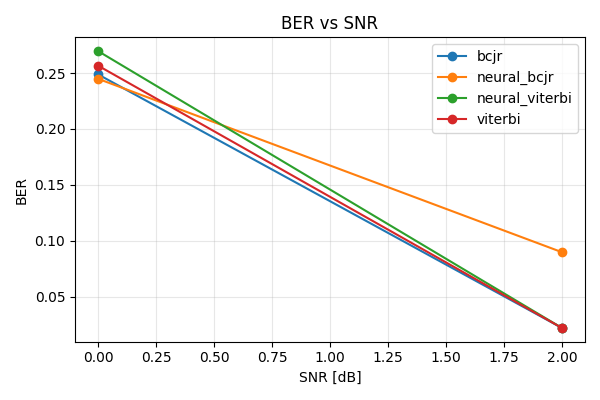

График FER
Ось X: SNR [dB] - отношение мощности сигнала к мощности шума
Ось Y: FER - доля блоков, в которых возникла хотя бы одна ошибка; меньше - лучше


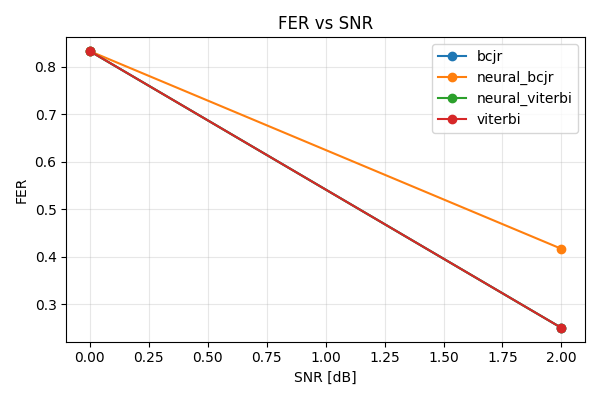

График времени декодирования
Ось X: SNR [dB] - отношение мощности сигнала к мощности шума
Ось Y: Decode time [s] - среднее время декодирования в секундах; меньше - быстрее


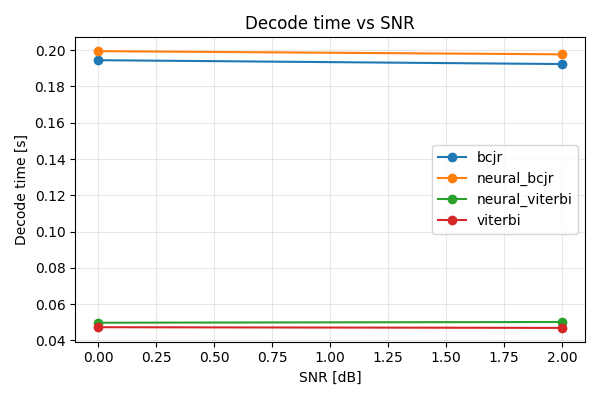

Краткий вывод по графикам:
- лучший BER: bcjr
- лучший FER: bcjr
- самый быстрый: viterbi
- основной итог этого ноутбука: вы увидели весь pipeline на небольшом примере; подробное итоговое сравнение всех алгоритмов находится в ноутбуке 04.


In [7]:
# [7/8] Графики с пояснением
print('График BER')
print('Ось X: SNR [dB] - отношение мощности сигнала к мощности шума')
print('Ось Y: BER - доля ошибочно восстановленных битов; меньше - лучше')
display(Image(filename=str(out_dir / 'ber_plot.png')))

print('График FER')
print('Ось X: SNR [dB] - отношение мощности сигнала к мощности шума')
print('Ось Y: FER - доля блоков, в которых возникла хотя бы одна ошибка; меньше - лучше')
display(Image(filename=str(out_dir / 'fer_plot.png')))

print('График времени декодирования')
print('Ось X: SNR [dB] - отношение мощности сигнала к мощности шума')
print('Ось Y: Decode time [s] - среднее время декодирования в секундах; меньше - быстрее')
display(Image(filename=str(out_dir / 'timing_plot.png')))

if 'results' in globals():
    grouped = results.groupby('decoder', as_index=False).agg(ber=('ber','mean'), fer=('fer','mean'), t=('decode_time_s','mean'))
    print('Краткий вывод по графикам:')
    print('- лучший BER:', grouped.loc[grouped['ber'].idxmin(), 'decoder'])
    print('- лучший FER:', grouped.loc[grouped['fer'].idxmin(), 'decoder'])
    print('- самый быстрый:', grouped.loc[grouped['t'].idxmin(), 'decoder'])
    print('- основной итог этого ноутбука: вы увидели весь pipeline на небольшом примере; подробное итоговое сравнение всех алгоритмов находится в ноутбуке 04.')

In [8]:
# [8/8] Проверяем, какие файлы появились
for p in sorted(out_dir.iterdir()):
    print('-', p.name)


- ber_plot.png
- checkpoints
- config_used.yaml
- fer_plot.png
- results.csv
- run_metadata.json
- signals.npz
- summary.md
- timing_plot.png


## Итог quickstart
Этот ноутбук показывает общий ход эксперимента и помогает быстро проверить, что пайплайн работает. Если нужен основной вывод по сравнению алгоритмов, открывайте `04_compare_all.ipynb`. Если нужно понять воспроизводимость запуска на одинаковых сигналах, открывайте `05_reproduce_from_saved_signals.ipynb`.